# Notebook 09: Grid Along-Track Retrievals onto a 6.25 km Polar Stereographic Grid

This notebook addresses Alex’s comment 4 on the M2 manuscript: the current along-track version of Figure 3 suffers from severe overplotting. To resolve this, the notebook grids valid CRYO2ICE snow-thickness retrievals onto the NSIDC Southern Hemisphere polar stereographic grid at 6.25 km resolution (i.e., half the AMSR2 12.5 km grid spacing) and computes the median snow thickness within each grid cell.

## Input

- `snow_thickness_with_amsr2_all.csv` (generated from NB05 / batch pipeline)

## Outputs

- `fig03_gridded_snow_map_6250m.png`
- `fig03_gridded_snow_map_6250m.pdf`
- `gridded_snow_thickness_6250m.nc`

## Key updates relative to the current Figure 3

1. Replaces along-track scatter with gridded median snow thickness to eliminate overplotting.
2. Restricts the analysis to the Weddell and Ross sectors only, excluding the Bellingshausen–Amundsen and East Antarctic sectors.
3. Uses a 6.25 km grid resolution consistent with half the AMSR2 12.5 km grid spacing.

## 9.1 Setup and Imports

In [13]:
import sys, os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import rcParams
warnings.filterwarnings('ignore')

sys.path.insert(0, '/g/data/gv90/xl1657/phd/M2_workspace/notebooks')

# ─── Paths ───────────────────────────────────────────────────────
HS_DIR  = '/g/data/gv90/xl1657/phd/M2_workspace/output/snow_thickness'
FIG_DIR = '/g/data/gv90/xl1657/phd/M2_workspace/output/figures'
os.makedirs(FIG_DIR, exist_ok=True)

# ─── Nature publication style (consistent with 07_final) ─────────
rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': 7,
    'axes.labelsize': 8,
    'axes.titlesize': 9,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 6.5,
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.4,
    'ytick.major.width': 0.4,
    'xtick.major.size': 2.5,
    'ytick.major.size': 2.5,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'lines.linewidth': 0.8,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.02,
    'pdf.fonttype': 42,
    'figure.dpi': 150,
})

# ─── Okabe–Ito palette ──────────────────────────────────────────
C_WEDDELL = '#0072B2'
C_ROSS    = '#D55E00'

# ─── Check for pyresample ────────────────────────────────────────
try:
    from pyresample import create_area_def
    from pyresample.bucket import BucketResampler
    print('pyresample available')
except ImportError:
    print('pyresample NOT found. Install with:')
    print('  pip install --user pyresample')
    raise

# ─── Check for cartopy ──────────────────────────────────────────
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    has_cartopy = True
    print('cartopy available')
except ImportError:
    has_cartopy = False
    print('cartopy NOT available — will produce non-projected fallback plot')

print('\nSetup complete')

pyresample available
cartopy available

Setup complete


## 9.2 Load Data and Filter to Weddell + Ross Winter

In [14]:
# ─── Load combined dataset ────────────────────────────────────────
CACHE = f'{HS_DIR}/snow_thickness_with_amsr2_all.csv'
df = pd.read_csv(CACHE)
print(f'Loaded {len(df):,} total matchups')

# ─── Parse year/month, assign sectors (same logic as 07_final) ───
df['year']  = df['year_month'].astype(str).str[:4].astype(int)
df['month'] = df['year_month'].astype(str).str[4:6].astype(int)

def assign_sector(lon):
    if -62 <= lon <= 15:
        return 'Weddell'
    elif (160 <= lon <= 180) or (-180 <= lon <= -140):
        return 'Ross'
    else:
        return 'Other'

df['sector'] = df['lon'].apply(assign_sector)
df['is_winter'] = df['month'].isin([5, 6, 7, 8, 9, 10])

# ─── Filter: winter, valid hs > 0, Weddell or Ross only ─────────
mask = df['is_winter'] & (df['snow_thickness'] > 0) & df['sector'].isin(['Weddell', 'Ross'])
dv = df[mask].copy()

print(f'Valid winter Weddell+Ross retrievals: {len(dv):,}')
print(f'  Weddell: {(dv.sector == "Weddell").sum():,}')
print(f'  Ross:    {(dv.sector == "Ross").sum():,}')
print(f'  Lon range: [{dv.lon.min():.1f}, {dv.lon.max():.1f}]')
print(f'  Lat range: [{dv.lat.min():.1f}, {dv.lat.max():.1f}]')

Loaded 126,283 total matchups
Valid winter Weddell+Ross retrievals: 72,907
  Weddell: 42,447
  Ross:    30,460
  Lon range: [-180.0, 180.0]
  Lat range: [-77.6, -58.1]


## 9.3 Define the 6.25 km Southern Hemisphere Polar Stereographic Grid

The NSIDC Southern Hemisphere polar stereographic grid has the following characteristics:

- **Projection:** Polar Stereographic
- **Latitude of true scale:** 70°S
- **Datum:** WGS84
- **Grid extent:** ±3950 km from the South Pole
- **Grid resolution:** 6.25 km
- **Grid dimensions:** 1264 × 1264 pixels

In [15]:
# ─── Define target grid at 6.25 km resolution ────────────────────
area_def = create_area_def(
    'south_polar_6250m',
    {
        'proj': 'stere',
        'lat_0': -90,
        'lon_0': 0,
        'lat_ts': -70,          # true-scale latitude
        'a': 6378137,            # WGS84 semi-major
        'b': 6356752.3142,       # WGS84 semi-minor
    },
    area_extent=(-3950000, -3950000, 3950000, 3950000),
    resolution=6250              # 6.25 km in metres
)

print(f'Grid shape (rows, cols): {area_def.shape}')
print(f'Grid extent: {area_def.area_extent}')
print(f'Pixel size: 6.25 km × 6.25 km')
print(f'Total grid cells: {area_def.shape[0] * area_def.shape[1]:,}')

Grid shape (rows, cols): (1264, 1264)
Grid extent: (-3950000.0, -3950000.0, 3950000.0, 3950000.0)
Pixel size: 6.25 km × 6.25 km
Total grid cells: 1,597,696


## 9.4 Grid Retrievals Using a Bucket Resampler

Each retrieval is assigned to its nearest grid cell. For grid cells containing multiple retrievals, we compute the **median** snow thickness, which is more robust than the mean for the right-skewed distribution of retrieved values. We also record the number of retrievals contributing to each grid cell.

In [16]:
import dask.array as da

lons = dv['lon'].values.astype(np.float64)
lats = dv['lat'].values.astype(np.float64)
hs_vals = dv['snow_thickness'].values.astype(np.float64)

# ─── Wrap as dask arrays (required by pyresample BucketResampler) ─
lons_da = da.from_array(lons, chunks=-1)
lats_da = da.from_array(lats, chunks=-1)
hs_da   = da.from_array(hs_vals, chunks=-1)

# ─── Create bucket resampler ─────────────────────────────────────
resampler = BucketResampler(area_def, lons_da, lats_da)
print('BucketResampler created')

# ─── Compute per-cell count ──────────────────────────────────────
gridded_count = resampler.get_count()
if hasattr(gridded_count, 'compute'):
    gridded_count = gridded_count.compute()
print(f'Grid cells with data: {(gridded_count > 0).sum():,}')

# ─── Compute per-cell statistics via bin indices ─────────────────
# The resampler assigns each point to a flattened grid index
idxs = resampler.idxs
if hasattr(idxs, 'compute'):
    idxs = idxs.compute()

ny, nx = area_def.shape
n_cells = ny * nx

gridded_median = np.full(n_cells, np.nan)
gridded_mean   = np.full(n_cells, np.nan)
gridded_std    = np.full(n_cells, np.nan)
gridded_q25    = np.full(n_cells, np.nan)
gridded_q75    = np.full(n_cells, np.nan)

# Group points by grid cell
valid_mask = idxs >= 0
unique_bins = np.unique(idxs[valid_mask])
print(f'Unique bins with data: {len(unique_bins):,}')

for b in unique_bins:
    pts = hs_vals[idxs == b]
    gridded_median[b] = np.nanmedian(pts)
    gridded_mean[b]   = np.nanmean(pts)
    if len(pts) >= 2:
        gridded_std[b] = np.nanstd(pts)
        gridded_q25[b] = np.nanpercentile(pts, 25)
        gridded_q75[b] = np.nanpercentile(pts, 75)

# ─── Reshape to 2D ───────────────────────────────────────────────
gridded_median = gridded_median.reshape((ny, nx))
gridded_mean   = gridded_mean.reshape((ny, nx))
gridded_std    = gridded_std.reshape((ny, nx))
gridded_q25    = gridded_q25.reshape((ny, nx))
gridded_q75    = gridded_q75.reshape((ny, nx))
if gridded_count.ndim == 1:
    gridded_count = gridded_count.reshape((ny, nx))

# ─── Summary statistics ──────────────────────────────────────────
filled = gridded_count > 0
print(f'  Grid summary:')
print(f'  Filled cells:           {filled.sum():,}')
print(f'  Median of cell medians: {np.nanmedian(gridded_median[filled]):.3f} m')
print(f'  Mean of cell medians:   {np.nanmean(gridded_median[filled]):.3f} m')
print(f'  Max points in one cell: {gridded_count.max()}')


BucketResampler created
Grid cells with data: 12,445
Unique bins with data: 12,445
  Grid summary:
  Filled cells:           12,445
  Median of cell medians: 0.129 m
  Mean of cell medians:   0.178 m
  Max points in one cell: 32


## 9.5 Plot Gridded Map — Single Circumpolar View (Mean Snow Thickness)

Single circumpolar polar stereographic view with sector boundaries
drawn in sector colours (blue for Weddell, orange for Ross) and
labelled with their defining longitudes. Annotation boxes report
the number of filled cells, mean, and median for each sector.
Colormap uses RdPu to avoid conflict with sector colours.



  GRIDDING AT 6.25 km
  Grid shape: 1264 x 1264 = 1,597,696 cells
  Filled cells: 12,445 of 1,597,696 (0.8%)
  Mean of cell means: 0.190 m
  Weddell: 7,098 cells, mean=0.203 m, median=0.156 m
  Ross:    5,344 cells, mean=0.172 m, median=0.131 m
  NetCDF saved: /g/data/gv90/xl1657/phd/M2_workspace/output/snow_thickness/gridded_snow_thickness_6250m.nc


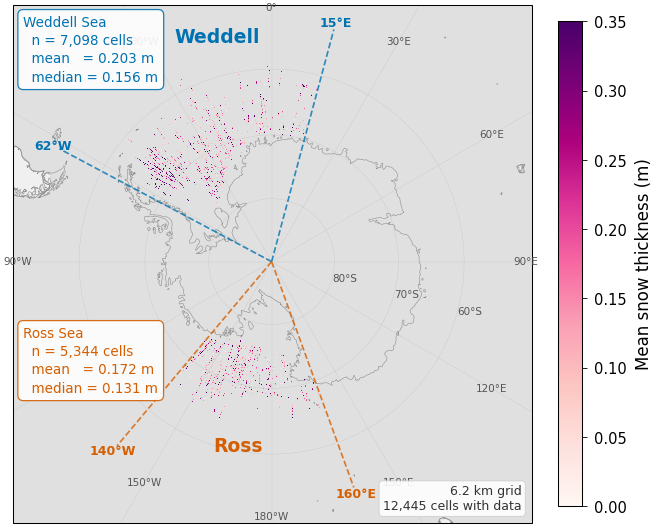

  Figure saved: /g/data/gv90/xl1657/phd/M2_workspace/output/figures/fig03_gridded_snow_map_6250m.pdf

  GRIDDING AT 12.5 km
  Grid shape: 632 x 632 = 399,424 cells
  Filled cells: 7,045 of 399,424 (1.8%)
  Mean of cell means: 0.189 m
  Weddell: 3,982 cells, mean=0.202 m, median=0.158 m
  Ross:    3,060 cells, mean=0.171 m, median=0.135 m
  NetCDF saved: /g/data/gv90/xl1657/phd/M2_workspace/output/snow_thickness/gridded_snow_thickness_12500m.nc


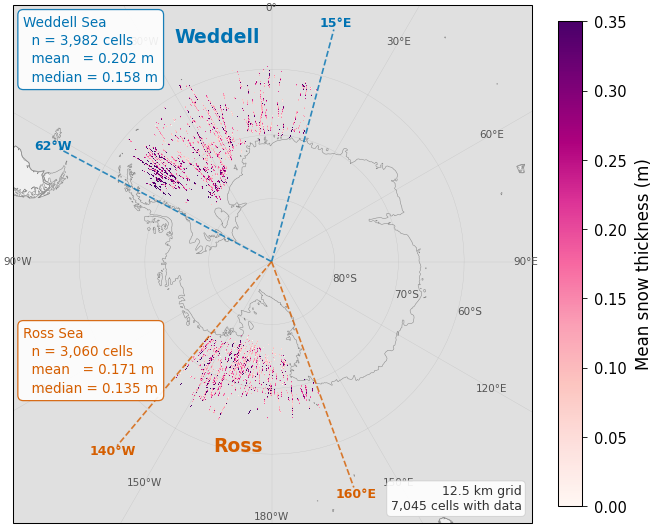

  Figure saved: /g/data/gv90/xl1657/phd/M2_workspace/output/figures/fig03_gridded_snow_map_12500m.pdf

  GRIDDING AT 25.0 km
  Grid shape: 316 x 316 = 99,856 cells
  Filled cells: 3,651 of 99,856 (3.7%)
  Mean of cell means: 0.185 m
  Weddell: 2,064 cells, mean=0.197 m, median=0.160 m
  Ross:    1,585 cells, mean=0.168 m, median=0.140 m
  NetCDF saved: /g/data/gv90/xl1657/phd/M2_workspace/output/snow_thickness/gridded_snow_thickness_25000m.nc


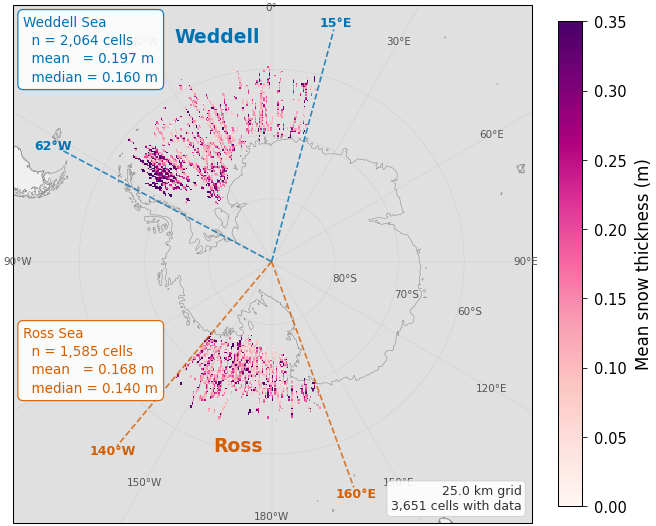

  Figure saved: /g/data/gv90/xl1657/phd/M2_workspace/output/figures/fig03_gridded_snow_map_25000m.pdf

  GRIDDING AT 50.0 km
  Grid shape: 158 x 158 = 24,964 cells
  Filled cells: 1,648 of 24,964 (6.6%)
  Mean of cell means: 0.181 m
  Weddell: 954 cells, mean=0.193 m, median=0.162 m
  Ross:    691 cells, mean=0.163 m, median=0.143 m
  NetCDF saved: /g/data/gv90/xl1657/phd/M2_workspace/output/snow_thickness/gridded_snow_thickness_50000m.nc


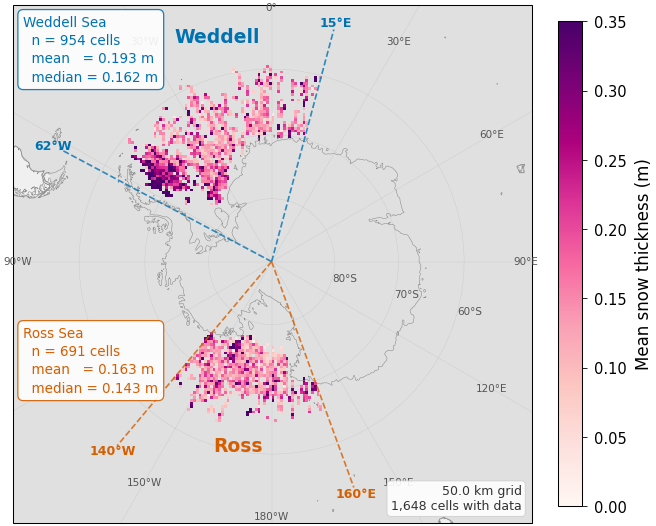

  Figure saved: /g/data/gv90/xl1657/phd/M2_workspace/output/figures/fig03_gridded_snow_map_50000m.pdf

════════════════════════════════════════════════════════════
  All resolutions complete.
  Figures in: /g/data/gv90/xl1657/phd/M2_workspace/output/figures
  NetCDFs in: /g/data/gv90/xl1657/phd/M2_workspace/output/snow_thickness
════════════════════════════════════════════════════════════


In [17]:
# ================================================================
# FIGURE 3: Multi-resolution gridded maps (6.25, 12.5, 25, 50 km)
#
# Replaces Cells 6 + 8 + 10 + 12 in 09_gridded_map_v3.ipynb.
# Run AFTER Cells 2 (setup) and 4 (data loading/filtering).
#
# Addresses Alex's comments:
#   1. Add 50 km resolution to minimise gaps
#   2. Distinguish no-data (light grey) from zero snow (colourmap low end)
#
# Produces four figures + four NetCDF files.
# ================================================================

import dask.array as da
from pyresample import create_area_def
from pyresample.bucket import BucketResampler
from pyproj import Transformer
from matplotlib.colors import ListedColormap

# ─── Resolutions to produce (metres) ─────────────────────────────
resolutions = [6250, 12500, 25000, 50000]

# ─── Source data arrays (from Cell 4 filtering) ──────────────────
lons = dv['lon'].values.astype(np.float64)
lats = dv['lat'].values.astype(np.float64)
hs_vals = dv['snow_thickness'].values.astype(np.float64)

lons_da = da.from_array(lons, chunks=-1)
lats_da = da.from_array(lats, chunks=-1)

# ─── Sector assignment function ──────────────────────────────────
def cell_sector(lon):
    if -62 <= lon <= 15:
        return 'Weddell'
    elif (160 <= lon <= 180) or (-180 <= lon <= -140):
        return 'Ross'
    return 'Other'

# ─── Projection for coordinate conversion ────────────────────────
proj_str = '+proj=stere +lat_0=-90 +lon_0=0 +lat_ts=-70 +a=6378137 +b=6356752.3142'
transformer = Transformer.from_crs(proj_str, 'EPSG:4326', always_xy=True)

# ─── Colourmap with distinct no-data background ──────────────────
# Problem: RdPu starts at white, same as no-data background.
# Solution: Set no-data to light grey (#e0e0e0) via set_bad(),
#           and ensure the colourmap low end starts above white.
#
# We modify RdPu so its lowest value is a very pale pink (#fef0f5)
# rather than pure white, making even 0.00 m distinguishable from
# the grey no-data background.
cmap = plt.cm.RdPu.copy()
cmap.set_bad(color='#e0e0e0')    # no-data cells → light grey
cmap.set_under(color='#e0e0e0')  # values below vmin → same grey

vmin, vmax = 0, 0.35

# ─── No-data ocean background colour ─────────────────────────────
# We also need the map background (ocean where no sea ice exists)
# to be the same grey, so it is visually consistent.
NODATA_COLOUR = '#e0e0e0'


for res_m in resolutions:
    res_km = res_m / 1000
    half = res_m / 2
    print(f'\n{"="*60}')
    print(f'  GRIDDING AT {res_km} km')
    print(f'{"="*60}')

    # ── Define target grid ───────────────────────────────────────
    area_def = create_area_def(
        f'south_polar_{res_m}m',
        {
            'proj': 'stere',
            'lat_0': -90,
            'lon_0': 0,
            'lat_ts': -70,
            'a': 6378137,
            'b': 6356752.3142,
        },
        area_extent=(-3950000, -3950000, 3950000, 3950000),
        resolution=res_m
    )
    ny, nx = area_def.shape
    n_cells = ny * nx
    print(f'  Grid shape: {ny} x {nx} = {n_cells:,} cells')

    # ── Bucket resampling ────────────────────────────────────────
    resampler = BucketResampler(area_def, lons_da, lats_da)

    gridded_count = resampler.get_count()
    if hasattr(gridded_count, 'compute'):
        gridded_count = gridded_count.compute()

    idxs = resampler.idxs
    if hasattr(idxs, 'compute'):
        idxs = idxs.compute()

    # ── Compute per-cell statistics ──────────────────────────────
    gridded_median = np.full(n_cells, np.nan)
    gridded_mean   = np.full(n_cells, np.nan)
    gridded_std    = np.full(n_cells, np.nan)
    gridded_q25    = np.full(n_cells, np.nan)
    gridded_q75    = np.full(n_cells, np.nan)

    valid_mask = idxs >= 0
    unique_bins = np.unique(idxs[valid_mask])

    for b in unique_bins:
        pts = hs_vals[idxs == b]
        gridded_median[b] = np.nanmedian(pts)
        gridded_mean[b]   = np.nanmean(pts)
        if len(pts) >= 2:
            gridded_std[b] = np.nanstd(pts)
            gridded_q25[b] = np.nanpercentile(pts, 25)
            gridded_q75[b] = np.nanpercentile(pts, 75)

    # ── Reshape to 2D ────────────────────────────────────────────
    gridded_median = gridded_median.reshape((ny, nx))
    gridded_mean   = gridded_mean.reshape((ny, nx))
    gridded_std    = gridded_std.reshape((ny, nx))
    gridded_q25    = gridded_q25.reshape((ny, nx))
    gridded_q75    = gridded_q75.reshape((ny, nx))
    if gridded_count.ndim == 1:
        gridded_count = gridded_count.reshape((ny, nx))

    filled = gridded_count > 0
    print(f'  Filled cells: {filled.sum():,} of {n_cells:,} '
          f'({100*filled.sum()/n_cells:.1f}%)')
    print(f'  Mean of cell means: {np.nanmean(gridded_mean[filled]):.3f} m')

    # ── Coordinate arrays (cell centres) ─────────────────────────
    x_centres = np.linspace(area_def.area_extent[0] + half,
                            area_def.area_extent[2] - half, nx)
    y_centres = np.linspace(area_def.area_extent[3] - half,
                            area_def.area_extent[1] + half, ny)

    # ── Sector statistics (from filled cell centres) ─────────────
    row_idx, col_idx = np.where(filled)
    x_filled = x_centres[col_idx]
    y_filled = y_centres[row_idx]
    lon_filled, lat_filled = transformer.transform(x_filled, y_filled)
    hs_filled = gridded_mean[filled]

    cell_sectors = np.array([cell_sector(lo) for lo in lon_filled])

    w_mask = cell_sectors == 'Weddell'
    r_mask = cell_sectors == 'Ross'
    w_n = (~np.isnan(hs_filled[w_mask])).sum()
    w_mean_v = np.nanmean(hs_filled[w_mask])
    w_median = np.nanmedian(hs_filled[w_mask])
    r_n = (~np.isnan(hs_filled[r_mask])).sum()
    r_mean_v = np.nanmean(hs_filled[r_mask])
    r_median = np.nanmedian(hs_filled[r_mask])

    print(f'  Weddell: {w_n:,} cells, '
          f'mean={w_mean_v:.3f} m, median={w_median:.3f} m')
    print(f'  Ross:    {r_n:,} cells, '
          f'mean={r_mean_v:.3f} m, median={r_median:.3f} m')

    # ══════════════════════════════════════════════════════════════
    # SAVE NetCDF
    # ══════════════════════════════════════════════════════════════
    try:
        import xarray as xr

        ds = xr.Dataset({
            'snow_thickness_median': (['y', 'x'], gridded_median),
            'snow_thickness_mean':   (['y', 'x'], gridded_mean),
            'snow_thickness_std':    (['y', 'x'], gridded_std),
            'snow_thickness_q25':    (['y', 'x'], gridded_q25),
            'snow_thickness_q75':    (['y', 'x'], gridded_q75),
            'count':                 (['y', 'x'], gridded_count),
        }, coords={
            'x': x_centres,
            'y': y_centres,
        })
        ds.attrs['projection'] = 'NSIDC Southern Polar Stereographic'
        ds.attrs['true_scale_latitude'] = -70.0
        ds.attrs['resolution_m'] = res_m
        ds.attrs['resolution_km'] = res_km
        ds.attrs['grid_shape'] = f'{ny} x {nx}'
        ds.attrs['description'] = (
            f'CRYO2ICE gridded snow thickness at {res_km} km, '
            f'austral winter (May-Oct) 2022-2025, '
            f'Weddell + Ross sectors only'
        )

        out_nc = f'{HS_DIR}/gridded_snow_thickness_{res_m}m.nc'
        ds.to_netcdf(out_nc)
        print(f'  NetCDF saved: {out_nc}')

    except ImportError:
        print('  xarray not available — skipping NetCDF export.')

    # ══════════════════════════════════════════════════════════════
    # PLOT
    # ══════════════════════════════════════════════════════════════
    if not has_cartopy:
        print('  Cartopy not available — skipping plot.')
        continue

    proj_crs = ccrs.SouthPolarStereo()

    fig = plt.figure(figsize=(140/25.4, 145/25.4))
    ax = fig.add_subplot(1, 1, 1, projection=proj_crs)
    ax.set_extent([-180, 180, -90, -50], ccrs.PlateCarree())

    # ── Set no-data background to light grey ─────────────────────
    # This makes the ocean/no-data areas grey, so they are visually
    # distinct from the colourmap's low end (pale pink for ~0 m snow).
    ax.set_facecolor(NODATA_COLOUR)

    # ── Basemap ──────────────────────────────────────────────────
    ax.add_feature(cfeature.LAND, facecolor='#f0f0f0',
                   edgecolor='#888888', linewidth=0.3)
    ax.coastlines(resolution='50m', linewidth=0.25, color='#888888')
    ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=False,
                 linewidth=0.15, alpha=0.3, color='grey',
                 xlocs=np.arange(-180, 180, 30),
                 ylocs=[-60, -70, -80])

    # ── Gridded data as filled pixels ────────────────────────────
    # np.ma.masked_where makes unfilled cells "bad" → rendered as
    # the cmap.set_bad() colour (light grey), matching the background.
    plot_data = np.ma.masked_where(gridded_count < 1, gridded_mean)
    xx, yy = np.meshgrid(x_centres, y_centres)

    pcm = ax.pcolormesh(xx, yy, plot_data,
                        cmap=cmap, vmin=vmin, vmax=vmax,
                        transform=proj_crs,
                        shading='nearest',
                        rasterized=True)

    # ── Sector boundary lines ────────────────────────────────────
    for lon_val in [-62, 15]:
        lats_l = np.linspace(-90, -53, 150)
        lons_l = np.full_like(lats_l, lon_val)
        ax.plot(lons_l, lats_l, transform=ccrs.PlateCarree(),
                color=C_WEDDELL, ls='--', lw=0.8, alpha=0.8)
        label = f'{abs(lon_val)}°W' if lon_val < 0 else f'{lon_val}°E'
        ax.text(lon_val, -52, label, transform=ccrs.PlateCarree(),
                fontsize=6, fontweight='bold', color=C_WEDDELL,
                ha='center', va='center')

    for lon_val in [160, -140]:
        lats_l = np.linspace(-90, -53, 150)
        lons_l = np.full_like(lats_l, lon_val)
        ax.plot(lons_l, lats_l, transform=ccrs.PlateCarree(),
                color=C_ROSS, ls='--', lw=0.8, alpha=0.8)
        label = f'{abs(lon_val)}°E' if lon_val > 0 else f'{abs(lon_val)}°W'
        ax.text(lon_val, -52, label, transform=ccrs.PlateCarree(),
                fontsize=6, fontweight='bold', color=C_ROSS,
                ha='center', va='center')

    # ── Sector name labels ───────────────────────────────────────
    ax.text(-14, -55, 'Weddell', transform=ccrs.PlateCarree(),
            fontsize=9, fontweight='bold', color=C_WEDDELL, ha='center')
    ax.text(-170, -60, 'Ross', transform=ccrs.PlateCarree(),
            fontsize=9, fontweight='bold', color=C_ROSS, ha='center')

    # ── Non-sector longitude labels ──────────────────────────────
    for lon in np.arange(-180, 180, 30):
        if any(abs(lon - sl) < 10 for sl in [-62, 15, 160, -140]):
            continue
        if lon == 0:
            label = '0°'
        elif lon > 0:
            label = f'{lon}°E'
        else:
            label = f'{abs(lon)}°W'
        ax.text(lon, -51, label, fontsize=5, ha='center', va='center',
                transform=ccrs.PlateCarree(), color='#555555')

    # ── Latitude labels ──────────────────────────────────────────
    for lat in [-60, -70, -80]:
        ax.text(105, lat, f'{abs(lat)}°S', fontsize=5,
                ha='left', va='center',
                transform=ccrs.PlateCarree(), color='#555555')

    # ── Annotation boxes ─────────────────────────────────────────
    ax.text(0.02, 0.98,
            f'Weddell Sea\n'
            f'  n = {w_n:,} cells\n'
            f'  mean   = {w_mean_v:.3f} m\n'
            f'  median = {w_median:.3f} m',
            transform=ax.transAxes, fontsize=6.5,
            va='top', ha='left', linespacing=1.4,
            color=C_WEDDELL, fontweight='normal',
            bbox=dict(boxstyle='round,pad=0.4', fc='white',
                      ec=C_WEDDELL, alpha=0.9, lw=0.6))

    ax.text(0.02, 0.38,
            f'Ross Sea\n'
            f'  n = {r_n:,} cells\n'
            f'  mean   = {r_mean_v:.3f} m\n'
            f'  median = {r_median:.3f} m',
            transform=ax.transAxes, fontsize=6.5,
            va='top', ha='left', linespacing=1.4,
            color=C_ROSS, fontweight='normal',
            bbox=dict(boxstyle='round,pad=0.4', fc='white',
                      ec=C_ROSS, alpha=0.9, lw=0.6))

    # ── Resolution label ─────────────────────────────────────────
    ax.text(0.98, 0.02,
            f'{res_km:.1f} km grid\n'
            f'{filled.sum():,} cells with data',
            transform=ax.transAxes, fontsize=6,
            va='bottom', ha='right', color='#333333',
            bbox=dict(boxstyle='round,pad=0.3', fc='white',
                      ec='#cccccc', alpha=0.9, lw=0.4))

    # ── Colourbar ────────────────────────────────────────────────
    cb = plt.colorbar(pcm, ax=ax, shrink=0.75, pad=0.04,
                      orientation='vertical')
    cb.set_label('Mean snow thickness (m)', fontsize=8)
    cb.ax.tick_params(labelsize=7)

    # ── Save ─────────────────────────────────────────────────────
    fname = f'{FIG_DIR}/fig03_gridded_snow_map_{res_m}m'
    plt.savefig(f'{fname}.png', dpi=300)
    plt.savefig(f'{fname}.pdf')
    plt.show()
    print(f'  Figure saved: {fname}.pdf')

print(f'\n{"═"*60}')
print(f'  All resolutions complete.')
print(f'  Figures in: {FIG_DIR}')
print(f'  NetCDFs in: {HS_DIR}')
print(f'{"═"*60}')

## 9.6 Save Gridded Data as NetCDF

In [12]:
# ================================================================
# Save gridded data as NetCDF — 6.25 km, 12.5 km, and 25 km
# ================================================================

import dask.array as da
from pyresample import create_area_def
from pyresample.bucket import BucketResampler

try:
    import xarray as xr
except ImportError:
    raise ImportError('xarray not available. Install with: pip install --user xarray netcdf4')

# ─── Source arrays (from Cell 4 filtering) ────────────────────────
lons_da = da.from_array(dv['lon'].values.astype(np.float64), chunks=-1)
lats_da = da.from_array(dv['lat'].values.astype(np.float64), chunks=-1)
hs_vals = dv['snow_thickness'].values.astype(np.float64)

resolutions = [6250, 12500, 25000]

for res_m in resolutions:
    res_km = res_m / 1000
    half = res_m / 2
    print(f'\n{"─"*50}')
    print(f'  Gridding and saving at {res_km} km')
    print(f'{"─"*50}')

    # ── Define target grid ───────────────────────────────────────
    area_def = create_area_def(
        f'south_polar_{res_m}m',
        {
            'proj': 'stere',
            'lat_0': -90,
            'lon_0': 0,
            'lat_ts': -70,
            'a': 6378137,
            'b': 6356752.3142,
        },
        area_extent=(-3950000, -3950000, 3950000, 3950000),
        resolution=res_m
    )
    ny, nx = area_def.shape
    n_cells = ny * nx

    # ── Bucket resampling ────────────────────────────────────────
    resampler = BucketResampler(area_def, lons_da, lats_da)

    gridded_count = resampler.get_count()
    if hasattr(gridded_count, 'compute'):
        gridded_count = gridded_count.compute()

    idxs = resampler.idxs
    if hasattr(idxs, 'compute'):
        idxs = idxs.compute()

    # ── Compute per-cell statistics ──────────────────────────────
    gridded_median = np.full(n_cells, np.nan)
    gridded_mean   = np.full(n_cells, np.nan)
    gridded_std    = np.full(n_cells, np.nan)
    gridded_q25    = np.full(n_cells, np.nan)
    gridded_q75    = np.full(n_cells, np.nan)

    valid_mask = idxs >= 0
    unique_bins = np.unique(idxs[valid_mask])

    for b in unique_bins:
        pts = hs_vals[idxs == b]
        gridded_median[b] = np.nanmedian(pts)
        gridded_mean[b]   = np.nanmean(pts)
        if len(pts) >= 2:
            gridded_std[b] = np.nanstd(pts)
            gridded_q25[b] = np.nanpercentile(pts, 25)
            gridded_q75[b] = np.nanpercentile(pts, 75)

    # ── Reshape to 2D ────────────────────────────────────────────
    gridded_median = gridded_median.reshape((ny, nx))
    gridded_mean   = gridded_mean.reshape((ny, nx))
    gridded_std    = gridded_std.reshape((ny, nx))
    gridded_q25    = gridded_q25.reshape((ny, nx))
    gridded_q75    = gridded_q75.reshape((ny, nx))
    if gridded_count.ndim == 1:
        gridded_count = gridded_count.reshape((ny, nx))

    # ── Coordinate arrays (cell centres) ─────────────────────────
    x_centres = np.linspace(area_def.area_extent[0] + half,
                            area_def.area_extent[2] - half, nx)
    y_centres = np.linspace(area_def.area_extent[3] - half,
                            area_def.area_extent[1] + half, ny)

    # ── Build xarray Dataset ─────────────────────────────────────
    ds = xr.Dataset({
        'snow_thickness_median': (['y', 'x'], gridded_median),
        'snow_thickness_mean':   (['y', 'x'], gridded_mean),
        'snow_thickness_std':    (['y', 'x'], gridded_std),
        'snow_thickness_q25':    (['y', 'x'], gridded_q25),
        'snow_thickness_q75':    (['y', 'x'], gridded_q75),
        'count':                 (['y', 'x'], gridded_count),
    }, coords={
        'x': x_centres,
        'y': y_centres,
    })
    ds.attrs['projection'] = 'NSIDC Southern Polar Stereographic'
    ds.attrs['true_scale_latitude'] = -70.0
    ds.attrs['resolution_m'] = res_m
    ds.attrs['resolution_km'] = res_km
    ds.attrs['grid_shape'] = f'{ny} x {nx}'
    ds.attrs['description'] = (
        f'CRYO2ICE gridded snow thickness at {res_km} km, '
        f'austral winter (May-Oct) 2022-2025, '
        f'Weddell + Ross sectors only'
    )

    # ── Save ─────────────────────────────────────────────────────
    out_nc = f'{HS_DIR}/gridded_snow_thickness_{res_m}m.nc'
    ds.to_netcdf(out_nc)

    filled = gridded_count > 0
    print(f'  Grid: {ny} x {nx} ({filled.sum():,} filled cells)')
    print(f'  Median of cell means: {np.nanmedian(gridded_mean[filled]):.3f} m')
    print(f'  Saved: {out_nc}')
    print(ds)

print(f'\n{"═"*50}')
print(f'  All three NetCDF files saved to {HS_DIR}')
print(f'{"═"*50}')


──────────────────────────────────────────────────
  Gridding and saving at 6.25 km
──────────────────────────────────────────────────
  Grid: 1264 x 1264 (12,445 filled cells)
  Median of cell means: 0.144 m
  Saved: /g/data/gv90/xl1657/phd/M2_workspace/output/snow_thickness/gridded_snow_thickness_6250m.nc
<xarray.Dataset>
Dimensions:                (y: 1264, x: 1264)
Coordinates:
  * x                      (x) float64 -3.947e+06 -3.941e+06 ... 3.947e+06
  * y                      (y) float64 3.947e+06 3.941e+06 ... -3.947e+06
Data variables:
    snow_thickness_median  (y, x) float64 nan nan nan nan ... nan nan nan nan
    snow_thickness_mean    (y, x) float64 nan nan nan nan ... nan nan nan nan
    snow_thickness_std     (y, x) float64 nan nan nan nan ... nan nan nan nan
    snow_thickness_q25     (y, x) float64 nan nan nan nan ... nan nan nan nan
    snow_thickness_q75     (y, x) float64 nan nan nan nan ... nan nan nan nan
    count                  (y, x) int64 0 0 0 0 0 0 0 0 0 .

## 9.7 Summary

**Key settings for the manuscript:**

- **Grid:** 6.25 km NSIDC Southern Hemisphere polar stereographic
- **Statistic plotted:** mean snow thickness per grid cell
- **Sectors shown:** Weddell (62°W–15°E) and Ross (160°E–140°W) only
- **Layout:** Single circumpolar view with sector-coloured boundaries
- **Colormap:** RdPu (avoids blue/orange sector colours)
- **Annotations:** n cells, mean, and median for each sector
